# Value at Risk Estimation and Backtesting for SENSEX Portfolios: Integrating Extreme Value Theory and GARCH Models

---

# Objective

- Estimate Value at Risk (VaR) for a portfolio constructed using SENSEX constituent stocks weighted as per index composition.
- Evaluate and compare multiple VaR estimation techniques:  
  Historical Simulation, Variance-Covariance, Monte Carlo, GARCH, EVT, and GARCH+EVT.
- Perform model backtesting using violation counts, violation ratio, and Kupiec test.
- Analyze model performance in both **normal** (2021-2022) and **stressed** (COVID-19: 2019-2020) market conditions.
- Apply **Extreme Value Theory (EVT)** to model tail risk, and integrate EVT with GARCH to improve risk quantification.

---

# Methodology

## Data Preparation
- Obtained historical adjusted closing prices (2015-2024) for the 30 SENSEX stocks from Yahoo Finance.
- Applied log return transformation and constructed a daily portfolio return series using SENSEX weights (as of Sep 2024).

## VaR Estimation Models

1. **Historical Simulation**  
   - Non-parametric percentile of past returns over rolling windows.

2. **Variance-Covariance (Parametric)**  
   - Assumes normal distribution of returns. VaR is computed using portfolio mean and standard deviation.

3. **Monte Carlo Simulation**  
   - Generates synthetic correlated returns using Cholesky decomposition and simulates portfolio return distribution.

4. **GARCH(1,1)**  
   - Models time-varying volatility in returns to estimate conditional VaR.

5. **EVT (Generalized Pareto Distribution)**  
   - Fits left-tail excess returns using GPD to better capture extreme losses.

6. **GARCH + EVT**  
   - Combines GARCH-based standardized residuals with GPD tail modeling for high-confidence VaR.

## Backtesting Approach

- Used a 250-day rolling window and computed 1-day VaR.
- Applied:
  - **Violation count**: Number of breaches of VaR
  - **Violation ratio**: Breaches vs expected number
  - **Kupiec test**: Likelihood ratio test to check statistical calibration
  - **Basel Traffic Light framework**: Red/Yellow/Green zone classification based on violations

---

# Key Achievements

- Implemented and compared **six VaR models**, including advanced EVT and GARCH+EVT methods.
- Demonstrated clear underperformance of parametric models in stressed markets.
- Showed **EVT-based models outperform** traditional models under extreme market conditions.
- Conducted robust backtesting using **Kupiec test and Basel framework**.
- Applied **Extreme Value Theory** to model the left tail of return distribution, with $R^2 \approx 0.90$ for GPD fit.
- Discovered **Student-t distribution fits returns better than Normal**, indicating heavy-tailed behavior.

---

## Key Results

### Normal Market (2022, 99% VaR):

| Method             | Violations | Kupiec p-value | Basel Zone |
|--------------------|------------|----------------|------------|
| Historical         | 2          | 0.74           | Green      |
| Variance-Covariance| 7          | 0.019          | Yellow     |
| Monte Carlo        | 7          | 0.019          | Yellow     |
| GARCH              | 4          | 0.38           | Green      |

### Stressed Market (2020, 99% VaR):

| Method             | Violations | Kupiec p-value | Basel Zone |
|--------------------|------------|----------------|------------|
| Historical         | 10         | 0.0003         | Red        |
| Variance-Covariance| 9          | 0.0014         | Red        |
| Monte Carlo        | 9          | 0.0014         | Red        |
| GARCH              | 13         | 0.000002       | Red        |
| EVT                | 9          | 0.0001         | Red        |
| GARCH + EVT        | 8          | 0.00004        | Yellow     |

---

### Insights from Return Distribution and Tail Modeling

- **Kurtosis ~ 21.8** confirms strong presence of fat tails.
- Student-t fit ($R^2 \approx 0.86$) outperforms Normal ($R^2 \approx 0.83$).
- GPD fit on the 5th percentile tail shows **$R^2 = 0.90$**, confirming suitability for EVT.
- Mean Excess Plot supports GPD assumptions for extreme loss modeling.

---

# Conclusion

- In normal conditions, all models perform acceptably, with Historical and GARCH methods passing both Kupiec test and Basel thresholds.
- During **stressed periods**, traditional methods fail to capture tail risk, leading to red-zone classification under Basel.
- **EVT-based methods, especially GARCH + EVT**, show better tail coverage with fewer violations and improved robustness.
- The study confirms that **Extreme Value Theory significantly enhances VaR accuracy** in volatile markets.


---


Required packages

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

import scipy.linalg
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import chi2, norm, t, genpareto, skew, kurtosis

from arch import arch_model

from statsmodels.distributions.empirical_distribution import ECDF
import statsmodels.api as sm

from sklearn.metrics import r2_score

np.random.seed(100)

## Data processing

We consider a portfolio with the same weightage as the SENSEX index (top 30 companies in the BSE). We calculate Value at Risk (VaR) at different confidence levels (90%, 95%, 97%, 99%) using a rolling window of 250 days (approximately 1 year) in normal condition as well as at stressed condition.

In [2]:
# The following data is downloaded from the BSE website. The data contains SENSEX stocks and weightage as on September 30, 2024. 
sensex_data=pd.read_csv("Sensex_data.csv")
sensex_data.head()

,Company Name,Stock Symbol (NSE),Weightage (%)
0,Adani Ports & Special Economic Zone Ltd,ADANIPORTS,1.09
1,Asian Paints Ltd.,ASIANPAINT,1.54
2,Axis Bank Ltd.,AXISBANK,3.61
3,Bajaj Finserv Ltd.,BAJAJFINSV,1.10
4,Bajaj Finance Ltd.,BAJFINANCE,2.21


In [3]:
sensex_stocks=sensex_data["Stock Symbol (NSE)"].to_numpy()
# ".NS" needs to be added as Yahoo Finance downloads the stock data in this way (".NS" represents NSE)
sensex_stocks=[symbol+".NS" for symbol in sensex_stocks]  
sensex_weightage=pd.to_numeric(sensex_data["Weightage (%)"]).to_numpy()
sensex_weightage=sensex_weightage/sensex_weightage.sum()  # So that the sum of weights is 1


We use the adjusted close price of each stocks for last 10 years (2015-2024) saved in SENSEX stocks return.csv file. Which can be downloaded from the folowing command too.

stock_data=yf.download(ticker_set, start=start_date, end=end_date,auto_adjust=False)['Adj Close']

In [4]:
stock_data=pd.read_csv("SENSEX stocks return.csv", parse_dates=["Date"], index_col='Date')
stock_data.index = pd.to_datetime(stock_data.index)
stock_return=np.log(stock_data/stock_data.shift(1)).dropna()  # We consider the log return
stock_return.head()

,ADANIPORTS.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,-0.000626,0.033988,0.022117,-0.008547,-0.016116,0.005907,-0.000965,0.013821,-0.003302,0.027989,...,0.011963,-0.002650,0.003973,0.004914,0.026431,0.015457,0.013229,0.004883,0.007868,0.029459
2015-01-05,0.013838,-0.000064,0.006299,-0.013376,-0.002617,-0.022439,-0.016963,-0.008479,0.005738,0.002068,...,0.001080,-0.011014,-0.007962,0.000605,0.023176,0.014382,-0.015313,-0.016825,0.008066,0.002040
2015-01-06,-0.006040,-0.024161,-0.036400,-0.023391,-0.002594,-0.007875,-0.027070,-0.015689,0.018763,-0.043344,...,-0.022571,-0.046447,-0.041955,-0.022260,-0.043706,-0.049691,-0.037563,-0.010784,-0.034805,-0.028461
2015-01-07,-0.002333,0.019894,-0.000802,-0.000854,0.020155,0.002397,-0.024048,0.002914,0.034508,-0.027411,...,0.014257,0.021534,0.000833,0.001545,-0.015172,-0.019354,-0.011883,-0.004683,0.005085,-0.003958
2015-01-08,0.041034,0.061135,0.006596,0.048653,-0.001704,0.017176,0.022876,0.020788,0.018716,0.026835,...,0.004346,-0.014443,0.015538,0.011052,0.036093,0.015437,0.010738,0.016598,-0.004549,0.025022


In [5]:
portfolio_return = stock_return @ sensex_weightage

## Part 1: VaR computation

Function to calculate VaR using Historical Simulation

In [6]:

def calculate_var_historical(portfolio,confidence_level):
    VaR_hist=[np.percentile(portfolio,100-cl) for cl in confidence_level]
    return VaR_hist
    

Function to calculate VaR using Variance-Covariance method

In [7]:

def calculate_var_varcov(portfolio,confidence_level):
    portfolio_mean=portfolio.mean()
    portfolio_std=portfolio.std()
    VaR_varcov=[stats.norm.ppf(1-cl/100)*portfolio_std+portfolio_mean for cl in confidence_level]
    return VaR_varcov
    

Function to calculate VaR using Monte Carlo Simulation

In [8]:

def calculate_var_monte_carlo(stock_return,weights,confidence_level,num_simulations=10**4):

    volatility = stock_return.std()
    drift=stock_return.mean()-0.5*(volatility**2)
    
    # Generate correlated random returns using Cholesky decomposition
    corr_matrix=stock_return.corr()
    cholesky_factor=scipy.linalg.cholesky(corr_matrix,lower=True)
    
    random_returns=np.random.normal(size=(len(weights),num_simulations))
    correlated_random_returns=np.dot(cholesky_factor,random_returns)
    
    simulated_returns=drift.values[:,None]+volatility.values[:,None]*correlated_random_returns
    simulated_portfolio_returns=np.dot(weights,simulated_returns)

    VaR_mc=[np.percentile(simulated_portfolio_returns, 100 - cl) for cl in confidence_level]
    
    return VaR_mc
    

Function to calculate VaR using GARCH

In [9]:
def calculate_var_garch(portfolio, confidence_level):
    dmeaned_portfolio = portfolio - portfolio.mean()
    model = arch_model(dmeaned_portfolio * 100, vol='Garch', p=1, q=1)
    garch_res = model.fit(disp='off')
    forecast = garch_res.forecast(horizon=1)
    sigma_t = np.sqrt(forecast.variance.iloc[-1, 0]) / 100
    VaR_garch=[stats.norm.ppf(1-cl/100) * sigma_t + portfolio.mean() for cl in confidence_level]
    return VaR_garch
    

### VaR computation in normal market condition

We used data of 2021 to 2022, a total of 500 days. Then with 250 day rolling window basis computed VaR using `Historical method`, `Variance-Covariance or Parametric method`, `Monte Carlo Simulation` and `GARCH method`  at different confidence level, and then backtest.

In [10]:
returns_21_22 = (stock_return.loc['2020-12-01':'2022-12-31']).tail(500)
portfolio_return_21_22 = returns_21_22 @ sensex_weightage


In [11]:

confidence_level=[90,95,97,99]
window_size=250


In [12]:
VaR_hist_portfolio = []
VaR_varcov_portfolio = []
VaR_mc_portfolio = []
VaR_garch_portfolio = []


for i in range(window_size, len(returns_21_22)):
    VaR_hist_portfolio.append(calculate_var_historical(portfolio_return_21_22[i-window_size:i],confidence_level))
    VaR_varcov_portfolio.append(calculate_var_varcov(portfolio_return_21_22[i-window_size:i],confidence_level))
    VaR_mc_portfolio.append(calculate_var_monte_carlo(returns_21_22.iloc[i-window_size:i],sensex_weightage,confidence_level))
    VaR_garch_portfolio.append(calculate_var_garch(portfolio_return_21_22[i-window_size:i],confidence_level))



In [13]:
portfolio_metrics=pd.DataFrame(
    data={"Actual return":portfolio_return_21_22[window_size:],
         },
    index= portfolio_return_21_22.index[window_size:]
)


for i,cl in enumerate(confidence_level):
    portfolio_metrics["VaR_hist "+str(cl)+"%"]=[x[i] for x in VaR_hist_portfolio]
    portfolio_metrics["VaR_varcov "+str(cl)+"%"]=[x[i] for x in VaR_varcov_portfolio]
    portfolio_metrics["VaR_mc "+str(cl)+"%"]=[x[i] for x in VaR_mc_portfolio]
    portfolio_metrics["VaR_garch "+str(cl)+"%"]=[x[i] for x in VaR_garch_portfolio]



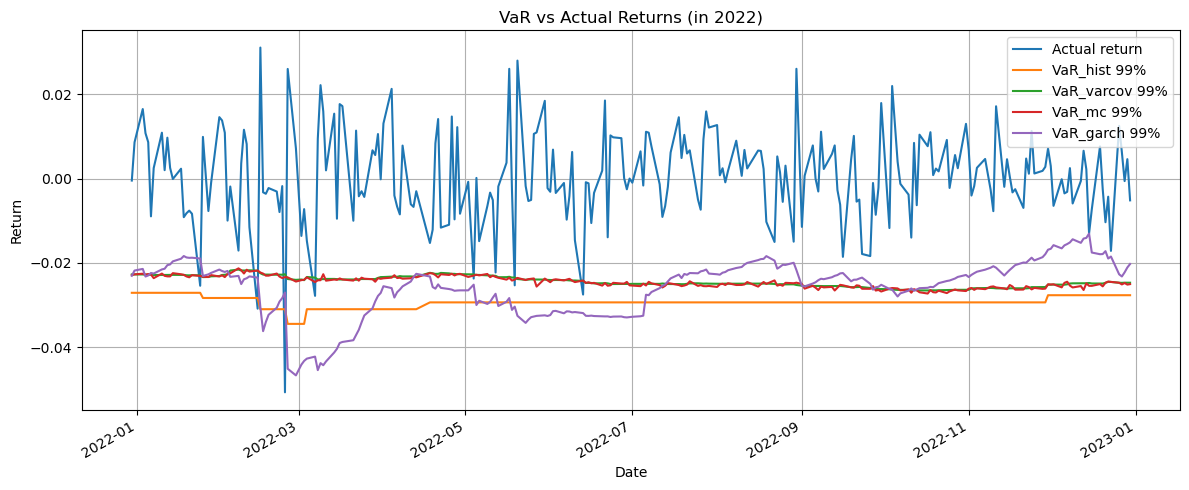

In [14]:
fig = portfolio_metrics[["Actual return", "VaR_hist 99%", "VaR_varcov 99%", "VaR_mc 99%", "VaR_garch 99%"]].plot(figsize=(12,5))
fig.set_xlabel("Date")
fig.set_ylabel("Return")
fig.grid(True)
plt.title("VaR vs Actual Returns (in 2022)")
plt.tight_layout()
plt.show()


In [15]:
(total_observations,tot_col)=portfolio_metrics.shape
model_violation=[(portfolio_metrics.iloc[:, i] > portfolio_metrics.iloc[:, 0]).sum() for i in range(1,tot_col)]
expected_violation=[round(total_observations*(1-(cl/100))) for cl in confidence_level]
    

In [16]:
violation_data=np.array(model_violation).reshape(len(confidence_level), 4)
violation_summary=pd.DataFrame(violation_data, columns=["Historical", "Variance-Covariance", "Monte-Carlo", "GARCH"],index=[str(x)+"%" for x in confidence_level])
violation_summary["Expected violation"]=expected_violation
violation_summary

,Historical,Variance-Covariance,Monte-Carlo,GARCH,Expected violation
90%,30,22,22,19,25
95%,12,11,12,15,13
97%,8,8,8,10,8
99%,2,7,7,4,3


### Violation Ratio in VaR Backtesting

The *Violation Ratio (VR)* checks if the actual number of VaR breaches aligns with expectations:
<br> $VR = \frac{x}{n \cdot \alpha}$

where:  
- $x$=Actual VaR breaches  
- $n$=Total observations  
- $\alpha$=VaR confidence level (e.g., for 99% VaR,=0.01).

**Interpretation:**
- $VR \approx 1$: Well-calibrated model  
- $VR>1$: Underestimates risk (too optimistic)  
- $VR < 1$: Overestimates risk (too conservative)
- Commonly, violation ratio in the range of $[0.8,1.2]$ considered as good. 


In [17]:
divisors=[total_observations*(1-(cl/100)) for cl in confidence_level]
violation_ratio=violation_summary.iloc[:,:4].div(divisors,axis=0)
violation_ratio


,Historical,Variance-Covariance,Monte-Carlo,GARCH
90%,1.200000,0.880000,0.880000,0.760000
95%,0.960000,0.880000,0.960000,1.200000
97%,1.066667,1.066667,1.066667,1.333333
99%,0.800000,2.800000,2.800000,1.600000


#### Violation Ratio analysis:

- All methods for calculating VaR perform reasonably well, except Variance-Covariance and Monte Carlo method at 99% confidence level.

### The Kupiec Test:
<br> Also known as the Proportion of Failures (POF) Test, is a statistical test used in Value-at-Risk (VaR) backtesting to verify whether the observed violations (losses exceeding VaR) occur at the expected frequency. It is based on a likelihood ratio (LR) test. <br> The null hypothesis $H_0$ assumes that the proportion of VaR violations matches the expected probability $\alpha$: <br> where:
- $p = \frac{x}{n}$ is the observed proportion of violations,
- $x$ is the number of observed VaR breaches,
- $n$ is the total number of observations,
- $\alpha$ is the expected violation rate (e.g., for 99\% VaR,  $\alpha$ = 0.01).
<br> The *Kupiec likelihood ratio statistic* is given by:
<br> $LR_{POF} = -2 \log \left( \frac{ (1 - \alpha)^{n - x} \alpha^x }{ (1 - p)^{n - x} p^x } \right)$

<br> Under the null hypothesis, $LR_{POF}$ follows a chi-square distribution with one degree of freedom.

<br> Generally, if p-value $> 0.05$ (that is at 95\% confidence level), we fail to reject $H_0$, indicating that the VaR model is correctly calibrated.



In [18]:
def calculate_kupiec_test_stat(violation_summary,confidence_level,total_observations,row,col):
    expected_prob=1-(confidence_level[row]/100)
    violations=violation_summary.iloc[row,col]
    violation_prob=violations/total_observations
    if violation_prob == 0:
        return 0

    
    LR=-2*np.log((((1-expected_prob)/(1-violation_prob)) ** (total_observations- violations)) *((expected_prob/violation_prob) ** violations))
    p_value=1-chi2.cdf(LR, df=1)
    return p_value
    

In [19]:
kupiec_test_p_value=pd.DataFrame(index=violation_ratio.index, columns=violation_ratio.columns)


for i in range(violation_ratio.shape[0]):  
    for j in range(violation_ratio.shape[1]):  
        kupiec_test_p_value.iloc[i, j] = calculate_kupiec_test_stat(violation_summary,confidence_level,total_observations,i, j)
kupiec_test_p_value

,Historical,Variance-Covariance,Monte-Carlo,GARCH
90%,0.305222,0.519365,0.519365,0.188411
95%,0.8839,0.657056,0.8839,0.481239
97%,0.854458,0.854458,0.854458,0.377293
99%,0.741933,0.019049,0.019049,0.380484


#### Conclusion from Kupiec Test:

- The results align with the violation ratio analysis, showing consistent performance for all methods, except Variance-Covariance method and Monte Carlo-Method at 99% confidence level.

### VaR computation in stressed market

We used data of 2019 to 2020, a total of 500 days. Then with 250 day rolling window basis computed VaR using `Historical method`, `Variance-Covariance or Parametric method`, `Monte Carlo Simulation` and `GARCH method` at different confidence level, and then backtest. This covers the period of COVID crisis where the market is stressed.

In [20]:
returns_19_20 = (stock_return.loc['2018-12-01':'2020-12-31']).tail(500)
portfolio_return_19_20 = returns_19_20 @ sensex_weightage


In [21]:
VaR_hist_portfolio = []
VaR_varcov_portfolio = []
VaR_mc_portfolio = []
VaR_garch_portfolio = []



for i in range(window_size, 500):
    VaR_hist_portfolio.append(calculate_var_historical(portfolio_return_19_20[i-window_size:i],confidence_level))
    VaR_varcov_portfolio.append(calculate_var_varcov(portfolio_return_19_20[i-window_size:i],confidence_level))
    VaR_mc_portfolio.append(calculate_var_monte_carlo(returns_19_20.iloc[i-window_size:i],sensex_weightage,confidence_level))
    VaR_garch_portfolio.append(calculate_var_garch(portfolio_return_19_20[i-window_size:i],confidence_level))

    
    

In [22]:
portfolio_metrics_19_20=pd.DataFrame(
    data={"Actual return":portfolio_return_19_20[window_size:],
         },
    index= portfolio_return_19_20.index[window_size:]
)


for i,cl in enumerate(confidence_level):
    portfolio_metrics_19_20["VaR_hist "+str(cl)+"%"]=[x[i] for x in VaR_hist_portfolio]
    portfolio_metrics_19_20["VaR_varcov "+str(cl)+"%"]=[x[i] for x in VaR_varcov_portfolio]
    portfolio_metrics_19_20["VaR_mc "+str(cl)+"%"]=[x[i] for x in VaR_mc_portfolio]
    portfolio_metrics_19_20["VaR_garch "+str(cl)+"%"]=[x[i] for x in VaR_garch_portfolio]
    portfolio_metrics_19_20["VaR_garch "+str(cl)+"%"]=[x[i] for x in VaR_garch_portfolio]



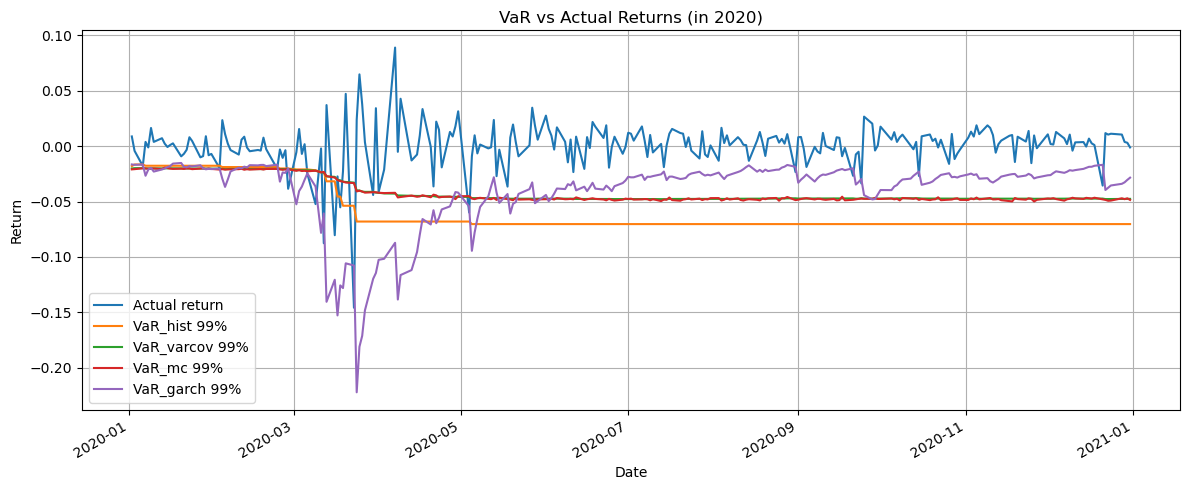

In [23]:
fig = portfolio_metrics_19_20[["Actual return", "VaR_hist 99%", "VaR_varcov 99%", "VaR_mc 99%", "VaR_garch 99%"]].plot(figsize=(12,5))
fig.set_xlabel("Date")
fig.set_ylabel("Return")
fig.grid(True)
plt.title("VaR vs Actual Returns (in 2020)")
plt.tight_layout()
plt.show()


In [24]:
(total_observations,tot_col)=portfolio_metrics_19_20.shape
model_violation=[(portfolio_metrics_19_20.iloc[:, i] > portfolio_metrics_19_20.iloc[:, 0]).sum() for i in range(1,tot_col)]
expected_violation=[round(total_observations*(1-(cl/100))) for cl in confidence_level]
    

In [25]:
violation_data=np.array(model_violation).reshape(len(confidence_level), 4)
violation_summary=pd.DataFrame(violation_data, columns=["Historical", "Variance-Covariance", "Monte-Carlo", "GARCH"],index=[str(x)+"%" for x in confidence_level])
violation_summary["Expected violation"]=expected_violation
violation_summary

,Historical,Variance-Covariance,Monte-Carlo,GARCH,Expected violation
90%,32,22,22,29,25
95%,22,18,17,19,13
97%,16,14,14,16,8
99%,10,9,9,13,3


In [26]:
divisors=[total_observations*(1-(cl/100)) for cl in confidence_level]
violation_ratio=violation_summary.iloc[:,:4].div(divisors,axis=0)
violation_ratio


,Historical,Variance-Covariance,Monte-Carlo,GARCH
90%,1.280000,0.880000,0.880000,1.160000
95%,1.760000,1.440000,1.360000,1.520000
97%,2.133333,1.866667,1.866667,2.133333
99%,4.000000,3.600000,3.600000,5.200000


In [27]:
kupiec_test_p_value=pd.DataFrame(index=violation_ratio.index, columns=violation_ratio.columns)


for i in range(violation_ratio.shape[0]):  
    for j in range(violation_ratio.shape[1]):  
        kupiec_test_p_value.iloc[i, j] = calculate_kupiec_test_stat(violation_summary,confidence_level,total_observations,i, j)
kupiec_test_p_value

,Historical,Variance-Covariance,Monte-Carlo,GARCH
90%,0.155329,0.519365,0.519365,0.409622
95%,0.012357,0.133139,0.214575,0.078749
97%,0.00601,0.031015,0.031015,0.00601
99%,0.000319,0.001382,0.001382,0.000002


Conclusion:

All methods failed the backtest at the 97% and 99% confidence levels, indicating that they were unable to adequately capture the tail risk during the stressed period.

## Part 2: Return Distribution and Extreme Value Theory Fitting

Summary statistics:
Mean: 0.0005958306937687705
Std Dev: 0.010758955634559374
Skewness: -1.4641806932438204
Kurtosis: 21.844635085794962
Normal fit: mu = 0.000596, std = 0.010757
Student-t fit: df = 3.77, mu = 0.000000, std = 0.007101
R^2 for Normal fit: 0.8331
R^2 for Student-t fit: 0.8611


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


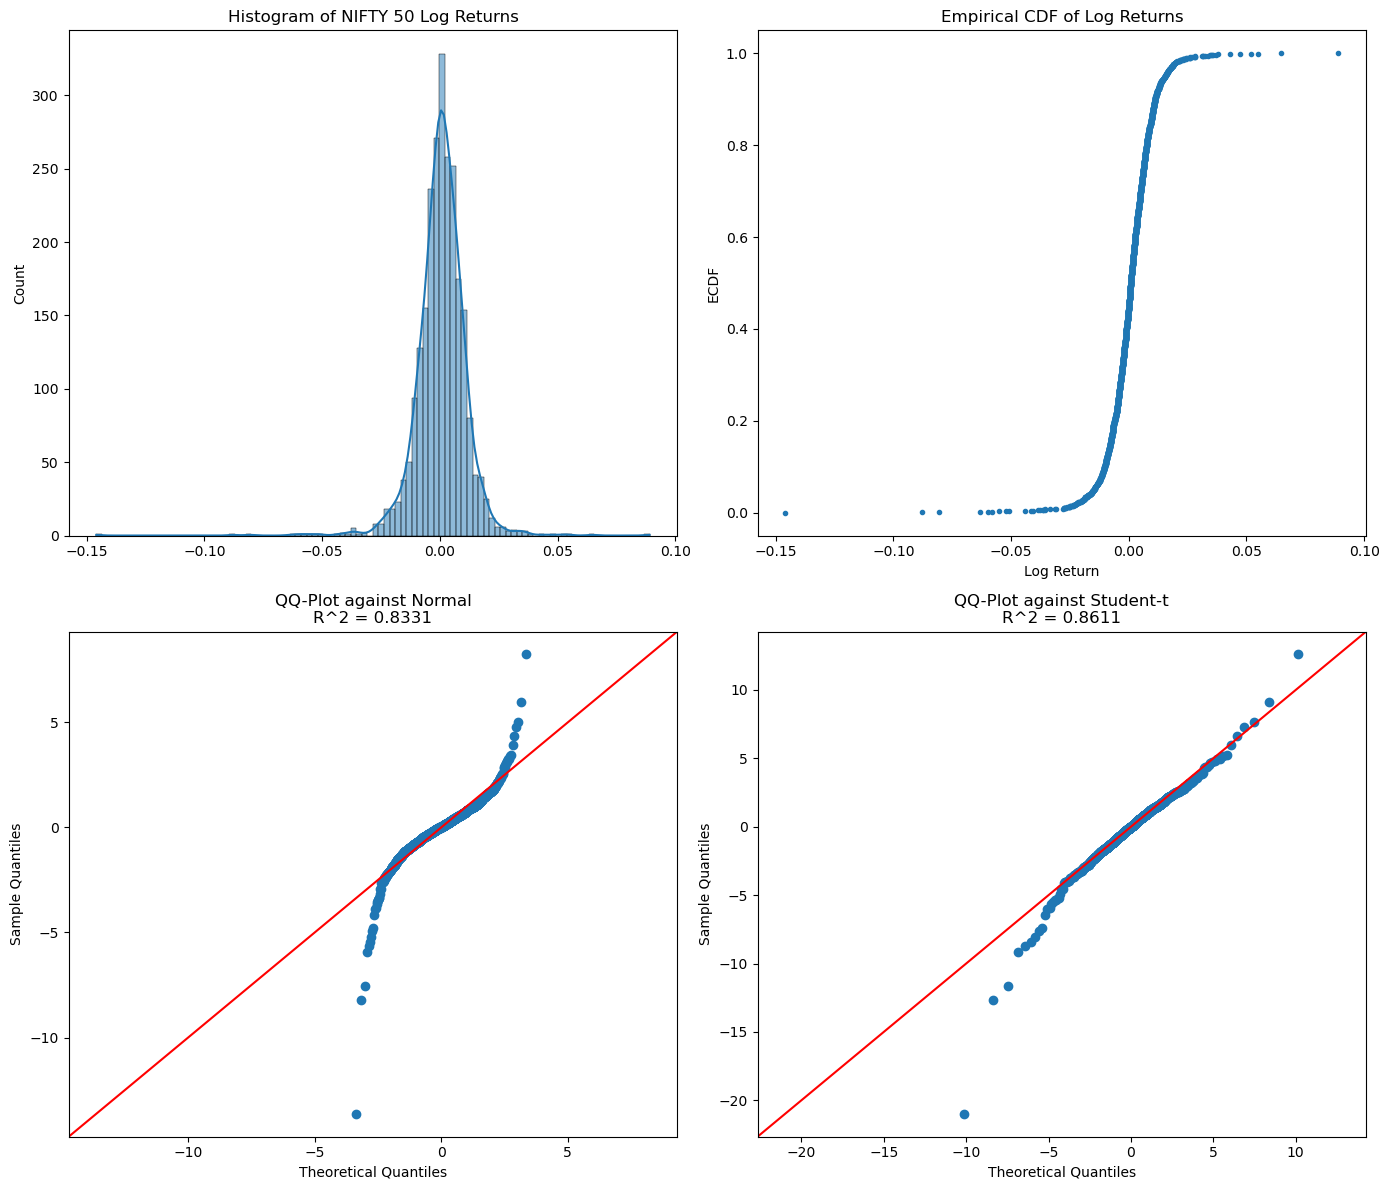

In [28]:
returns = portfolio_return.copy()


print("Summary statistics:")
print(f"Mean: {returns.mean()}")
print(f"Std Dev: {returns.std()}")
print(f"Skewness: {skew(returns)}")
print(f"Kurtosis: {kurtosis(returns)}")


mu_norm, std_norm = norm.fit(returns)
df_t, mu_t, std_t = t.fit(returns, floc=0)

print(f"Normal fit: mu = {mu_norm:.6f}, std = {std_norm:.6f}")
print(f"Student-t fit: df = {df_t:.2f}, mu = {mu_t:.6f}, std = {std_t:.6f}")


returns_sorted = np.sort(returns)
quantiles = np.linspace(0.01, 0.99, len(returns_sorted))


norm_theoretical = norm.ppf(quantiles, loc=mu_norm, scale=std_norm)
t_theoretical = t.ppf(quantiles, df=df_t, loc=mu_t, scale=std_t)


r2_norm = r2_score(returns_sorted, norm_theoretical)
r2_t = r2_score(returns_sorted, t_theoretical)

print(f"R^2 for Normal fit: {r2_norm:.4f}")
print(f"R^2 for Student-t fit: {r2_t:.4f}")


ecdf = ECDF(returns)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))


sns.histplot(returns, bins=100, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histogram of NIFTY 50 Log Returns")

# ECDF
axes[0, 1].plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
axes[0, 1].set_title("Empirical CDF of Log Returns")
axes[0, 1].set_xlabel("Log Return")
axes[0, 1].set_ylabel("ECDF")


sm.qqplot(returns, dist=norm, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title(f'QQ-Plot against Normal\nR^2 = {r2_norm:.4f}')


sm.qqplot(returns, dist=t, distargs=(df_t,), line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title(f'QQ-Plot against Student-t\nR^2 = {r2_t:.4f}')

plt.tight_layout()
#plt.savefig("normal-t-fit-r2.png")
plt.show()

Conclusions: The Student-t distribution fits the (SENSEX weightage) portfolio log returns better than the Normal distribution, as indicated by a higher $R^2$ (0.86 vs. 0.83). Its low degrees of freedom $\approx$ 4 ) capture the observed heavy tails in the data (kurtosis $\approx$ 21.84), making it more suitable for modeling extreme returns and tail risk.

R² for GPD left-tail fit: 0.9026


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


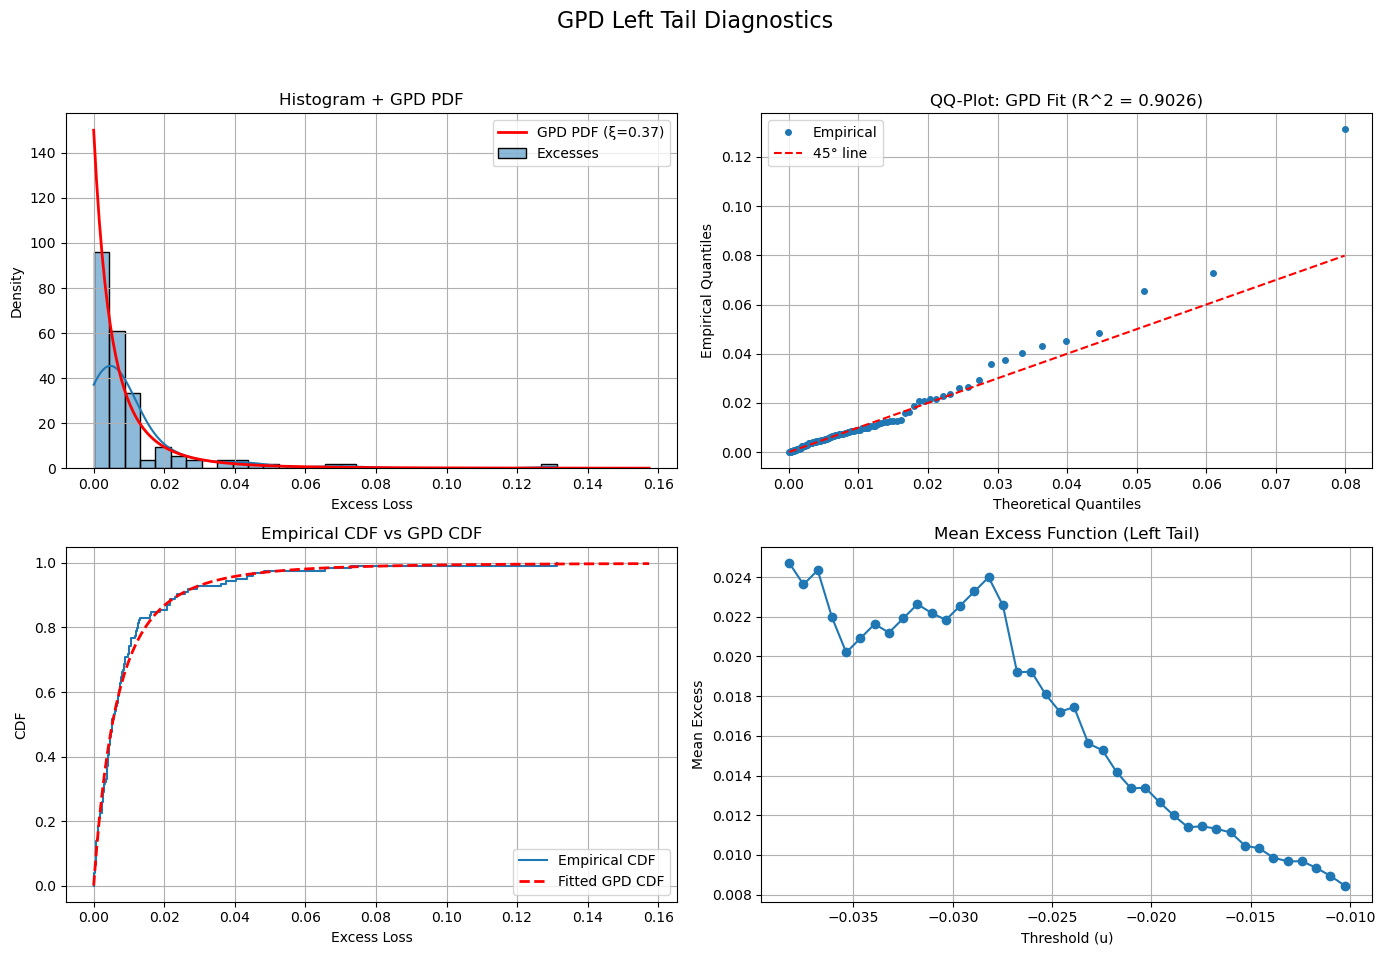

In [29]:
threshold_left = np.percentile(returns, 5)
excess_left = threshold_left - returns[returns < threshold_left]


shape_left, loc_left, scale_left = genpareto.fit(excess_left, floc=0)

emp_excess = np.sort(excess_left)
quantiles = np.linspace(0.01, 0.99, len(emp_excess))
theor_excess = genpareto.ppf(quantiles, c=shape_left, loc=0, scale=scale_left)


r2_gpd = r2_score(emp_excess, theor_excess)
print(f"R² for GPD left-tail fit: {r2_gpd:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GPD Left Tail Diagnostics", fontsize=16)


x = np.linspace(0, max(excess_left) * 1.2, 200)
pdf_fitted = genpareto.pdf(x, c=shape_left, loc=0, scale=scale_left)
sns.histplot(excess_left, bins=30, stat='density', ax=axes[0, 0], label='Excesses', kde=True)
axes[0, 0].plot(x, pdf_fitted, 'r-', lw=2, label=f'GPD PDF (ξ={shape_left:.2f})')
axes[0, 0].set_title("Histogram + GPD PDF")
axes[0, 0].set_xlabel("Excess Loss")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()
axes[0, 0].grid(True)


emp_excess = np.sort(excess_left)
theor_q = genpareto.ppf(np.linspace(0.01, 0.99, len(emp_excess)), c=shape_left, loc=0, scale=scale_left)
axes[0, 1].plot(theor_q, emp_excess, 'o', markersize=4, label='Empirical')
axes[0, 1].plot(theor_q, theor_q, 'r--', label='45° line')
axes[0, 1].set_title(f"QQ-Plot: GPD Fit (R^2 = {r2_gpd:.4f})")
axes[0, 1].set_xlabel("Theoretical Quantiles")
axes[0, 1].set_ylabel("Empirical Quantiles")
axes[0, 1].legend()
axes[0, 1].grid(True)


ecdf = ECDF(excess_left)
cdf_vals = genpareto.cdf(x, c=shape_left, loc=0, scale=scale_left)
axes[1, 0].step(ecdf.x, ecdf.y, where='post', label='Empirical CDF')
axes[1, 0].plot(x, cdf_vals, 'r--', lw=2, label='Fitted GPD CDF')
axes[1, 0].set_title("Empirical CDF vs GPD CDF")
axes[1, 0].set_xlabel("Excess Loss")
axes[1, 0].set_ylabel("CDF")
axes[1, 0].legend()
axes[1, 0].grid(True)


thresholds = np.linspace(np.percentile(returns, 0.5), np.percentile(returns, 10), 40)
mean_excess = []
for u in thresholds:
    tail = returns[returns < u]
    if len(tail) > 0:
        mean_excess.append(np.mean(u - tail))
    else:
        mean_excess.append(np.nan)

axes[1, 1].plot(thresholds, mean_excess, marker='o')
axes[1, 1].set_title("Mean Excess Function (Left Tail)")
axes[1, 1].set_xlabel("Threshold (u)")
axes[1, 1].set_ylabel("Mean Excess")
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.savefig("gpd_fit.png")
plt.show()


We modeled the left tail of our (SENSEX weightage) portfolio log returns using a Generalized Pareto Distribution (GPD) for excess losses beyond the 5th percentile. The fitted GPD aligns well with the empirical histogram and ECDF, and the QQ plot shows a good match for most quantiles, with minor underestimation of extreme losses. The mean excess function is approximately linear above the threshold, supporting the use of GPD in this region. The goodness-of-fit is further confirmed by a high $R^2$ value of 0.90. Overall, the GPD is a reasonable choice for modeling left-tail risk and estimating high-confidence risk measures like Value at Risk (VaR).

## Part 3: EVT based VaR computation and backtest

In [30]:
def calculate_var_evt(data, confidence_level, threshold_pct):
    threshold = np.percentile(data, threshold_pct)
    tail_data = threshold - data[data < threshold]  # excesses



    shape, loc, scale = genpareto.fit(tail_data, floc=0)
    p_tail = len(tail_data) / len(data)

    VaR_evt = [threshold - genpareto.ppf(1 - (1 - cl/100) / p_tail, c=shape, loc=0, scale=scale) for cl in confidence_level]
    return VaR_evt

In [31]:
def calculate_var_garch_evt(data, confidence_level, threshold_pct):
    demeaned_data = data - data.mean()
    model = arch_model(demeaned_data * 100, vol='Garch', p=1, q=1, dist = 't')
    res = model.fit(update_freq=0, disp='off')

    cond_vol = res.conditional_volatility / 100
    std_resids = (demeaned_data / cond_vol.shift(1)).dropna()

    var_std = calculate_var_evt(std_resids, confidence_level, threshold_pct)

    forecast = res.forecast(horizon=1)
    sigma_forecast = np.sqrt(forecast.variance.values[-1, 0]) / 100 
    
    var_actual = np.multiply(sigma_forecast , var_std) + data.mean()

    return var_actual


We use the same stressed market period (COVID crisis) to compute the 99% Value at Risk (VaR), applying a 250-day rolling window. The computed VaR is then backtested to evaluate the model's performance under extreme market conditions.

In [32]:
returns_19_20 = (returns.loc['2018-12-01':'2020-12-31']).tail(500)


In [33]:

confidence_level_ext = [99]
threshold_pct = 10
window_size = 250


In [34]:
VaR_evt_portfolio = []
VaR_garch_evt_portfolio = []

for i in range(window_size, len(returns_19_20)):
    VaR_evt_portfolio.append(calculate_var_evt(returns_19_20[i-window_size:i], confidence_level_ext, threshold_pct))
    VaR_garch_evt_portfolio.append(calculate_var_garch_evt(returns_19_20[i-window_size:i],confidence_level_ext, threshold_pct))
    

In [35]:
portfolio_metrics_ext=pd.DataFrame(
    data={"Actual return": returns_19_20[window_size:],
         },
    index=returns_19_20.index[window_size:]
)


for i,cl in enumerate(confidence_level_ext):
    portfolio_metrics_ext["VaR_evt "+str(cl)+"%"]=[x[i] for x in VaR_evt_portfolio]
    portfolio_metrics_ext["VaR_garch_evt "+str(cl)+"%"]=[x[i] for x in VaR_garch_evt_portfolio]



In [36]:
(total_observations,tot_col)=portfolio_metrics_ext.shape
model_violation=[(portfolio_metrics_ext.iloc[:, i] > portfolio_metrics_ext.iloc[:, 0]).sum() for i in range(1,tot_col)]
expected_violation=[round(total_observations*(1 - cl/100 )) for cl in confidence_level_ext]
    

In [37]:
violation_data=np.array(model_violation).reshape(len(confidence_level_ext), 2)
violation_summary=pd.DataFrame(violation_data, columns=["EVT", "GARCH+EVT"],index=[str(x)+"%" for x in confidence_level_ext])
violation_summary["Expected violation"]=expected_violation
violation_summary


,EVT,GARCH+EVT,Expected violation
99%,9,8,3


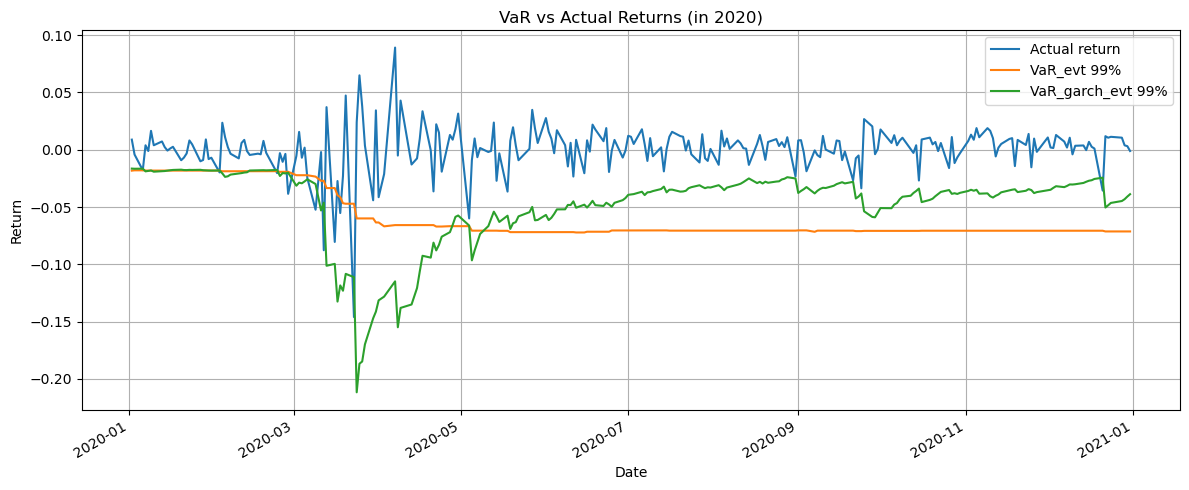

In [38]:
fig = portfolio_metrics_ext[["Actual return", "VaR_evt 99%", "VaR_garch_evt 99%"]].plot(figsize=(12,5))
fig.set_xlabel("Date")
fig.set_ylabel("Return")
fig.grid(True)
plt.title("VaR vs Actual Returns (in 2020)")
plt.tight_layout()
plt.show()


In [39]:
divisors=[total_observations*(1-(cl/100)) for cl in confidence_level_ext]
violation_ratio=violation_summary.iloc[:,:2].div(divisors,axis=0)
violation_ratio


,EVT,GARCH+EVT
99%,3.6,3.2


In [40]:
kupiec_test_p_value=pd.DataFrame(index=violation_ratio.index, columns=violation_ratio.columns)


for i in range(violation_ratio.shape[0]):  
    for j in range(violation_ratio.shape[1]):  
        kupiec_test_p_value.iloc[i, j] = calculate_kupiec_test_stat(violation_summary,confidence_level,total_observations,i, j)
kupiec_test_p_value

,EVT,GARCH+EVT
99%,0.000125,0.000037


## Conclusion: 99% VaR Backtesting and Basel Traffic Light Interpretation

- We performed 99% VaR backtesting on portfolio returns for the year 2020, which was a stressed market period due to the COVID-19 crash.
- Observed number of violations over **250 trading days** are summarized below:

| Method               | Violations |
|----------------------|------------|
| Historical           | 10         |
| Variance-Covariance  | 9          |
| Monte Carlo          | 9         |
| GARCH                | 13         |
| EVT                  | 9          |
| GARCH + EVT          | 8          |


### Basel Traffic Light Framework (for 250 observations):
- ** $\colorbox{green}{Green Zone}$**: 0-4 violations $\implies$ Model is acceptable
- ** $\colorbox{yellow}{Yellow Zone}$**: 5-9 violations $\implies$ Increased supervisory attention
- ** $\colorbox{red}{Red Zone }$**: 10 or more violations $\implies$ Model deemed inadequate

### Interpretation:
- All methods are in the **yellow or red zone** due to the stressed conditions.
- **EVT-based methods** (especially GARCH + EVT had **only 8 violations**, placing them in the **yellow zone**, suggesting better performance under tail risk.
- Traditional models like **Historical**, **Monte Carlo**, and **pure GARCH** exceeded 10 violations, entering the **red zone** and failing to capture tail risk effectively.

### Final Takeaway:
- **EVT-enhanced models** demonstrate **improved robustness** in modeling extreme losses during stressed markets.
- These methods are better suited for risk management when extreme events are more probable.
